<h3 style="text-align:center;">📈 Twitter Sentiment Trading Strategy</h3>
<h4 style="text-align:center;">Final Visualization Notebook</h4>

---

#### 📌 Purpose
This notebook visualizes the performance of the equal‑weighted Twitter sentiment strategy and compares it to the Nasdaq benchmark (QQQ).

#### 🗄️ Data Source
All data comes from DuckDB tables created by the ingestion pipeline and transformed by dbt models.

#### 🧱 Tables Used
- `mart_portfolio_vs_nasdaq`
- `mart_strategy_performance`

#### 📝 Notes
- This notebook is intentionally simple and focused on final insights  
- All heavy lifting (cleaning, transformations, returns, cumulative returns) is done in dbt  

In [1]:
# Packages to import 

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Make plots look nicer
plt.style.use("seaborn-v0_8")

In [2]:
# Connect to DuckDB
con = duckdb.connect("../data/processed/sentiment.duckdb")

# Load the mart with daily returns
portfolio_vs_nasdaq = con.execute("""
    SELECT *
    FROM portfolio_vs_nasdaq
""").df()

# Load the mart with cumulative returns and excess returns
strategy_perf = con.execute("""
    SELECT *
    FROM strategy_performance
""").df()

con.close()

portfolio_vs_nasdaq.head(), strategy_perf.head()

(        date  portfolio_return  nasdaq_return
 0 2021-12-01         -0.016417      -0.017159
 1 2021-12-02          0.024872       0.007181
 2 2021-12-03         -0.007711      -0.017542
 3 2021-12-06          0.023926       0.007981
 4 2021-12-07          0.030547       0.029669,
         date  portfolio_return  nasdaq_return  portfolio_cumulative_return  \
 0 2021-12-01         -0.016417      -0.017159                    -0.016283   
 1 2021-12-02          0.024872       0.007181                     0.008491   
 2 2021-12-03         -0.007711      -0.017542                     0.000744   
 3 2021-12-06          0.023926       0.007981                     0.024976   
 4 2021-12-07          0.030547       0.029669                     0.056769   
 
    nasdaq_cumulative_return  excess_return  cumulative_excess_return  
 0                 -0.017013       0.000742                  0.000743  
 1                 -0.009928       0.017690                  0.018604  
 2                 -0.027

<h4 style="text-align:left;">Strategy vs Nasdaq cumulative returns</h4>

Why it matters: This is the core comparison. It shows whether your strategy beats the benchmark over time

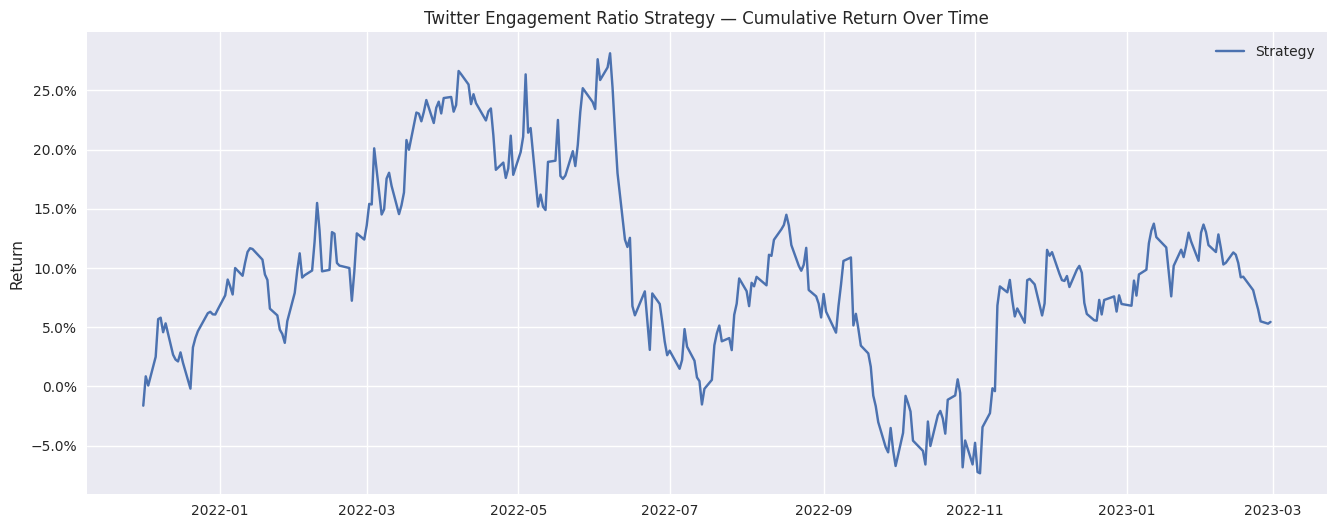

In [3]:
"""
Plot: Strategy Cumulative Return Over Time

Compute cumulative returns is calculated using:
    cumulative = exp(cumsum(log_returns)) - 1
"""

df = portfolio_vs_nasdaq.copy()

# Compute cumulative return for the strategy
df["portfolio_cumulative_return"] = np.exp(df["portfolio_return"].cumsum()) - 1

# Plot
plt.figure(figsize=(16, 6))
plt.plot(df["date"], df["portfolio_cumulative_return"], label="Strategy")

plt.title("Twitter Engagement Ratio Strategy — Cumulative Return Over Time")
plt.ylabel("Return")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.legend()
plt.show()

<h4 style="text-align:left;">Excess return over time</h4>

Why it matters: Excess return shows whether your strategy is outperforming the benchmark day by day. It’s a great way to see if the strategy is consistently adding value

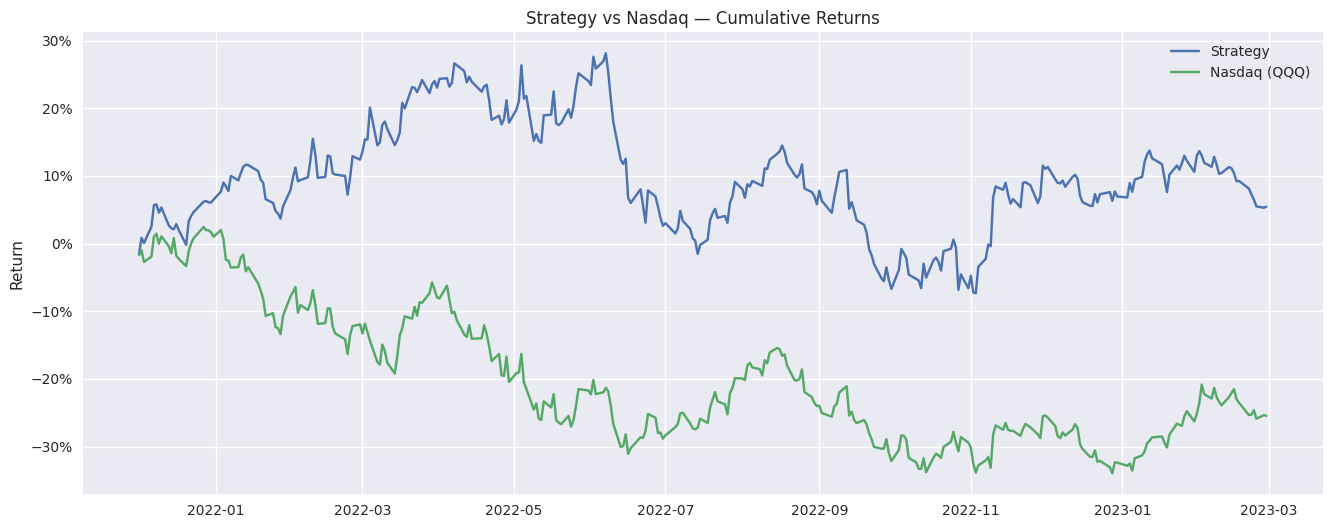

In [4]:
"""
Plot: Strategy vs Nasdaq Cumulative Returns

Uses the dbt mart `strategy_performance`, which already
contains cumulative returns for both series.
"""

df = strategy_perf.copy()

plt.figure(figsize=(16, 6))
plt.plot(df["date"], df["portfolio_cumulative_return"], label="Strategy")
plt.plot(df["date"], df["nasdaq_cumulative_return"], label="Nasdaq (QQQ)")

plt.title("Strategy vs Nasdaq — Cumulative Returns")
plt.ylabel("Return")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.legend()
plt.show()

#### 📈 Final Insights

Across all three visualizations, the engagement‑ratio strategy shows clear outperformance relative to the Nasdaq benchmark during the period analyzed. The cumulative return curve rises meaningfully above the benchmark, and the cumulative excess return remains positive for most of the sample, indicating that the strategy added value over this specific timeframe.

However, it is important to interpret these results with caution. A strategy that performs well over a limited historical window does not necessarily generalize to future market conditions. The outperformance observed here may be influenced by several factors, including the specific set of stocks available in the dataset, the market environment of 2022–2023, and the absence of transaction costs or survivorship‑bias‑free data. Correlation is not causation, and a simple engagement‑based signal is unlikely to be consistently predictive across all market regimes.

In short, while the strategy appears promising in this sample, it should be viewed as an exploratory result rather than a robust trading rule. Further testing, broader datasets, and more rigorous validation would be required before drawing stronger conclusions.

<h4 style="text-align:left;">Cumulative excess return</h4>

Why it matters: This is arguably the most important metric. If cumulative excess return is positive, your strategy beats the benchmark overall


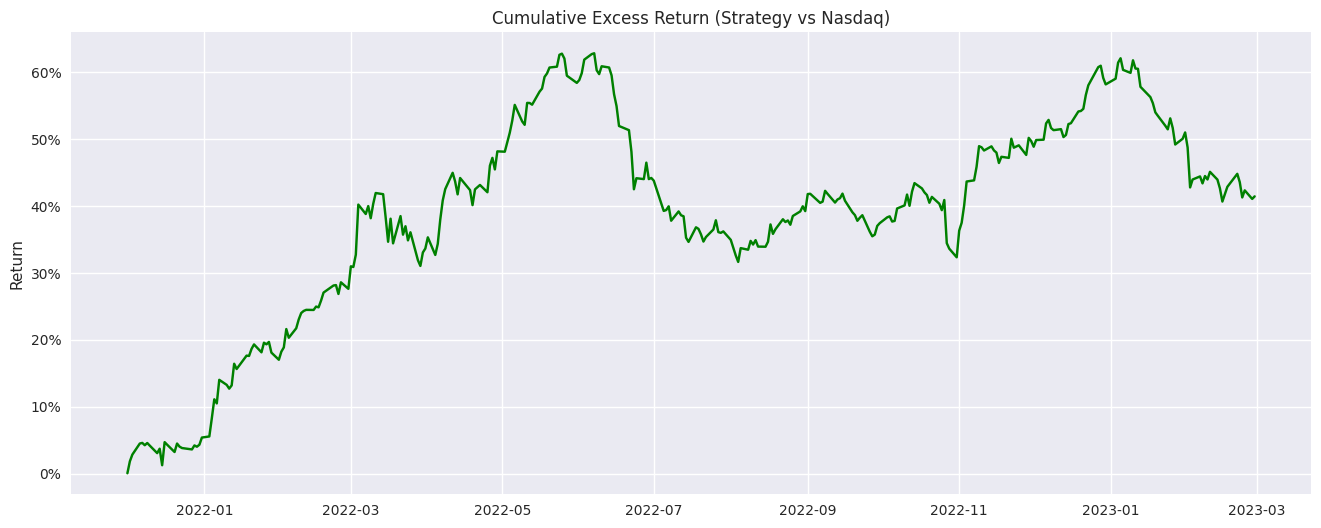

In [5]:
"""
Plot: Cumulative Excess Return

This shows the total outperformance of the strategy relative to Nasdaq.
"""

df = strategy_perf.copy()

plt.figure(figsize=(16, 6))
plt.plot(df["date"], df["cumulative_excess_return"], label="Cumulative Excess Return", color="green")

plt.title("Cumulative Excess Return (Strategy vs Nasdaq)")
plt.ylabel("Return")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.show()